# Notebook 3 — RF-DETR Nano Training
## KIIT-MiTA: High-Resolution Drone Imagery for Military Object Detection

**CSE 445 — Computer Vision**

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection), re-split output from Notebook 1 |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model trained here** | RF-DETR Nano (transformer / DETR family) |
| **Hardware** | Kaggle T4 x1 (single GPU) |

This notebook covers **Task 4.5** for RF-DETR Nano. Consistent with Notebook 2, all of RF-DETR's own
built-in augmentation/training defaults are used — no changes are made to match this to a specific
CNN-style augmentation pipeline, since RF-DETR's data pipeline and augmentation policy are internal
to the library and not exposed the same way Ultralytics' `train()` kwargs are.

---
## 1. Environment Setup
Install `rfdetr` (the official Roboflow package covering the whole RF-DETR family, Nano included) and
`supervision` (used later for test-set evaluation — kept separate from RF-DETR's own internal
validation loop so metrics are computed the same way, on the same held-out test split, for every
model in this project).

In [1]:
# install rfdetr WITH its training extras -- the bare `pip install rfdetr` only covers
# inference and is missing faster_coco_eval and other deps rfdetr.training needs internally
!pip install -q "rfdetr[train,loggers]" supervision pycocotools

import os, json, time, pathlib, yaml, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
from rfdetr import RFDETRNano
import supervision as sv

print("torch       :", torch.__version__)
print("cuda avail  :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device      :", torch.cuda.get_device_name(0))

import rfdetr
print("rfdetr      :", getattr(rfdetr, "__version__", "unknown"))
print("supervision :", sv.__version__)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406.

/usr/local/lib/python3.12/dist-packages/rfdetr/models/weights.py:258: FutureWarning: target=True is deprecated since `v0.8`; use `TargetMode.ARGS_REMAP` instead. Will be removed in `v1.0`.
  @deprecated(target=True, args_mapping={"train_config": None}, deprecated_in="1.7.0", remove_in="1.9.0", num_warns=-1)


---
## 2. CONFIG Cell
Same discipline as Notebook 2: every path and hyperparameter lives here, nowhere else.

In [2]:
# ==================== CONFIG CELL ====================
# All paths and shared settings live here. Do not hardcode dataset folder names.

def discover_data_yaml(search_base="/kaggle/input"):
    """Find the ORIGINAL data.yaml produced by Notebook 1 (relative paths, not the
    absolute-path copy Notebook 2 writes for itself). RF-DETR's YOLO-format
    auto-detection expects a data.yaml sitting at the dataset root with paths
    relative to that same root, same as Ultralytics does."""
    search = pathlib.Path(search_base)
    if not search.exists():
        search = pathlib.Path(".")
    candidates = list(search.rglob("data.yaml"))
    if not candidates:
        raise FileNotFoundError(
            f"Could not find data.yaml under {search_base}. "
            "Make sure the Notebook 1 resplit dataset is added as an input."
        )
    return candidates[0]

DATA_YAML = discover_data_yaml()
DATASET_DIR = DATA_YAML.parent   # RF-DETR's dataset_dir = the folder data.yaml lives in

with open(DATA_YAML) as f:
    _data_cfg = yaml.safe_load(f)

CLASS_NAMES = _data_cfg["names"]
NUM_CLASSES = _data_cfg["nc"]

_train_img_dir = DATASET_DIR / "train" / "images"
_train_lbl_dir = DATASET_DIR / "train" / "labels"
_val_img_dir   = DATASET_DIR / "val" / "images"
_val_lbl_dir   = DATASET_DIR / "val" / "labels"
_test_img_dir  = DATASET_DIR / "test" / "images"
_test_lbl_dir  = DATASET_DIR / "test" / "labels"

for _name, _d in [("train images", _train_img_dir), ("val images", _val_img_dir), ("test images", _test_img_dir)]:
    if not _d.exists():
        raise FileNotFoundError(f"Expected {_name} at {_d} but it does not exist.")

SEED = 42
OUTPUT_DIR = pathlib.Path("/kaggle/working/rfdetr_output")
CHECKPOINT_DIR = pathlib.Path("/kaggle/working/checkpoints")
RESULTS_JSON = pathlib.Path("/kaggle/working/model_results.json")  # same filename/schema as Notebook 2

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG_RFDETR = {
    "epochs": 50,
    "batch_size": 4,
    "grad_accum_steps": 4,        # effective batch = 4 x 4 x 1 GPU = 16, per RF-DETR's own guidance
    "lr": 1e-4,
    "seed": SEED,
    "early_stopping": True,
    "early_stopping_patience": 10,
    "early_stopping_min_delta": 0.005,
}

print(f"data.yaml         : {DATA_YAML}")
print(f"dataset_dir       : {DATASET_DIR}")
print(f"classes ({NUM_CLASSES})       : {CLASS_NAMES}")
print(f"output_dir        : {OUTPUT_DIR}")
print(f"checkpoint dir    : {CHECKPOINT_DIR}")
print(f"results log       : {RESULTS_JSON}")
print(f"\nCONFIG_RFDETR:")
for k, v in CONFIG_RFDETR.items():
    print(f"  {k:24s}: {v}")


data.yaml         : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/data.yaml
dataset_dir       : /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit
classes (7)       : ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']
output_dir        : /kaggle/working/rfdetr_output
checkpoint dir    : /kaggle/working/checkpoints
results log       : /kaggle/working/model_results.json

CONFIG_RFDETR:
  epochs                  : 50
  batch_size              : 4
  grad_accum_steps        : 4
  lr                      : 0.0001
  seed                    : 42
  early_stopping          : True
  early_stopping_patience : 10
  early_stopping_min_delta: 0.005


In [3]:
# ==================== FIX: rfdetr expects "valid", not "val" ====================

RFDETR_DATASET_DIR = pathlib.Path("/kaggle/working/dataset-rfdetr")
RFDETR_DATASET_DIR.mkdir(parents=True, exist_ok=True)

_alias_map = {"train": "train", "valid": "val", "test": "test"}
for _alias, _real in _alias_map.items():
    _link = RFDETR_DATASET_DIR / _alias
    _target = (DATASET_DIR / _real).resolve()
    if _link.exists() or _link.is_symlink():
        _link.unlink()
    _link.symlink_to(_target)

_rfdetr_yaml = {
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}
DATA_YAML = RFDETR_DATASET_DIR / "data.yaml"
with open(DATA_YAML, "w") as f:
    yaml.safe_dump(_rfdetr_yaml, f, default_flow_style=False, sort_keys=False)

# re-point everything downstream at the aliased layout
DATASET_DIR = RFDETR_DATASET_DIR
_train_img_dir = DATASET_DIR / "train" / "images"
_train_lbl_dir = DATASET_DIR / "train" / "labels"
_val_img_dir   = DATASET_DIR / "valid" / "images"
_val_lbl_dir   = DATASET_DIR / "valid" / "labels"
_test_img_dir  = DATASET_DIR / "test" / "images"
_test_lbl_dir  = DATASET_DIR / "test" / "labels"

print("DATASET_DIR now:", DATASET_DIR)
for p in sorted(DATASET_DIR.glob("*")):
    target = p.resolve() if p.is_symlink() else ""
    print(f"  {p.name:8s} -> {target}")
print(f"\ntrain images: {len(list(_train_img_dir.glob('*')))}")
print(f"valid images: {len(list(_val_img_dir.glob('*')))}")
print(f"test images : {len(list(_test_img_dir.glob('*')))}")

DATASET_DIR now: /kaggle/working/dataset-rfdetr
  data.yaml -> 
  test     -> /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/test
  train    -> /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/train
  valid    -> /kaggle/input/notebooks/arifulislamopi/notebook-1-dataset-eda/dataset-resplit/val

train images: 2377
valid images: 164
test images : 178


---
## 3. Dataset Preparation / Format Verification

RF-DETR (current `rfdetr` release) auto-detects the dataset format from the directory structure passed
to `dataset_dir`: it looks for `train/_annotations.coco.json` (COCO) or `data.yaml` + `train/images/`
(YOLO). Notebook 1's re-split output already has exactly the YOLO-format layout
(`data.yaml`, `train/images`, `train/labels`, ...), so in principle no conversion step is needed at all —
this is different from older RF-DETR guidance (COCO-only), so this cell verifies the assumption
explicitly rather than assuming it silently works.

If this cell's checks pass, Section 4's timing-probe run is the real test — if RF-DETR raises a
format-detection error there, use the fallback COCO-conversion cell (Section 3b) instead of
guessing further.

In [4]:
# ==================== DATASET FORMAT DIAGNOSTIC ====================

print("=" * 60)
print("RF-DETR DATASET FORMAT CHECK")
print("=" * 60)

print(f"dataset_dir       : {DATASET_DIR}")
print(f"data.yaml present : {DATA_YAML.exists()}")
print(f"train/images      : {_train_img_dir.exists()}  ({len(list(_train_img_dir.glob('*')))} files)")
print(f"train/labels      : {_train_lbl_dir.exists()}  ({len(list(_train_lbl_dir.glob('*')))} files)")
print(f"val/images        : {_val_img_dir.exists()}  ({len(list(_val_img_dir.glob('*')))} files)")
print(f"test/images       : {_test_img_dir.exists()}  ({len(list(_test_img_dir.glob('*')))} files)")

print(f"\ndata.yaml contents:")
with open(DATA_YAML) as f:
    print(f.read())

print("=" * 60)
print("If train/labels or val/images are missing/empty above, do NOT proceed to Section 4 —")
print("check that the Notebook 1 resplit dataset was attached as an input correctly.")
print("=" * 60)


RF-DETR DATASET FORMAT CHECK
dataset_dir       : /kaggle/working/dataset-rfdetr
data.yaml present : True
train/images      : True  (2377 files)
train/labels      : True  (2377 files)
val/images        : True  (164 files)
test/images       : True  (178 files)

data.yaml contents:
train: train/images
val: valid/images
test: test/images
nc: 7
names:
- Artilary
- Missile
- Radar
- M. Rocket Launcher
- Soldier
- Tank
- Vehicle

If train/labels or val/images are missing/empty above, do NOT proceed to Section 4 —
check that the Notebook 1 resplit dataset was attached as an input correctly.


### 3b. Fallback — YOLO → COCO Conversion (only run this if Section 4 errors out)
Not run by default. If RF-DETR's format auto-detection does not accept the structure verified above,
run this cell to build a COCO-format copy of the dataset in `/kaggle/working/dataset-coco/`
(images are hard-linked/copied, not re-encoded), then re-point `DATASET_DIR` at that copy before
re-running Section 4 onward.

In [5]:
# ==================== FALLBACK: YOLO -> COCO CONVERSION (not run by default) ====================
# Only execute this cell if Section 4's probe run fails with a dataset-format error.

def yolo_to_coco(images_dir, labels_dir, class_names, out_json_path):
    """Convert one YOLO-format split (images/ + labels/) into a single COCO
    _annotations.coco.json alongside it. Boxes are converted from normalised
    (cx, cy, w, h) to absolute COCO [x_min, y_min, w, h]."""
    images_dir = pathlib.Path(images_dir)
    labels_dir = pathlib.Path(labels_dir)

    categories = [{"id": i, "name": n, "supercategory": "none"} for i, n in enumerate(class_names)]
    images, annotations = [], []
    ann_id = 0

    for img_id, img_path in enumerate(sorted(images_dir.glob("*"))):
        with Image.open(img_path) as im:
            w, h = im.size
        images.append({"id": img_id, "file_name": img_path.name, "width": w, "height": h})

        lbl_path = labels_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cid = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                abs_w, abs_h = bw * w, bh * h
                x_min = (cx * w) - abs_w / 2
                y_min = (cy * h) - abs_h / 2
                annotations.append({
                    "id": ann_id, "image_id": img_id, "category_id": cid,
                    "bbox": [x_min, y_min, abs_w, abs_h],
                    "area": abs_w * abs_h, "iscrowd": 0,
                })
                ann_id += 1

    coco = {"images": images, "annotations": annotations, "categories": categories}
    with open(out_json_path, "w") as f:
        json.dump(coco, f)
    return len(images), len(annotations)


def build_coco_dataset(dataset_dir, out_dir, class_names):
    """Build a full COCO-format copy of the train/val/test splits."""
    dataset_dir = pathlib.Path(dataset_dir)
    out_dir = pathlib.Path(out_dir)
    for split in ["train", "val", "test"]:
        src_img = dataset_dir / split / "images"
        src_lbl = dataset_dir / split / "labels"
        if not src_img.exists():
            continue
        dst_img = out_dir / split
        dst_img.mkdir(parents=True, exist_ok=True)
        for p in src_img.glob("*"):
            dst = dst_img / p.name
            if not dst.exists():
                shutil.copy2(p, dst)
        n_img, n_ann = yolo_to_coco(src_img, src_lbl, class_names, dst_img / "_annotations.coco.json")
        print(f"{split}: {n_img} images, {n_ann} annotations -> {dst_img}")
    return out_dir

# To use this fallback:
# COCO_DATASET_DIR = build_coco_dataset(DATASET_DIR, "/kaggle/working/dataset-coco", CLASS_NAMES)
# DATASET_DIR = COCO_DATASET_DIR   # then re-run training with this instead
print("Fallback conversion function defined (not executed). Only call build_coco_dataset(...) if needed.")


Fallback conversion function defined (not executed). Only call build_coco_dataset(...) if needed.


---
## 4. Runtime Sanity Check
RF-DETR is architecturally very different from the YOLO CNNs in Notebook 2 (transformer backbone,
different memory/compute profile) — there is no existing timing reference for it on this dataset,
so this probes both the dataset format (Section 3) and per-epoch cost before committing to a full
50-epoch run, the same way Notebook 2 timed YOLOv10s before its full run.

In [6]:
# quick sanity check: 2 epochs to confirm the dataset format is accepted and to
# time a full 50-epoch run before committing to it
_probe_model = RFDETRNano()
_t0 = time.time()
_probe_model.train(
    dataset_dir=str(DATASET_DIR),
    epochs=2,
    batch_size=CONFIG_RFDETR["batch_size"],
    grad_accum_steps=CONFIG_RFDETR["grad_accum_steps"],
    lr=CONFIG_RFDETR["lr"],
    output_dir=str(OUTPUT_DIR / "_time_probe"),
    tensorboard=False,
)
_per_epoch_min = (time.time() - _t0) / 60 / 2
print(f"~{_per_epoch_min:.2f} min/epoch -> ~{_per_epoch_min*CONFIG_RFDETR['epochs']:.0f} min for the full {CONFIG_RFDETR['epochs']}-epoch run")
print("NOTE: like Notebook 2's probe, this includes one-time setup/download overhead in the")
print("first epoch, so it will likely over-estimate the real per-epoch cost of the full run.")


[2026-07-11 09:54:50] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-07-11 09:54:55] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-07-11 09:54:55] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-11 09:54:55] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-11 09:54:57] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

Trainable params: 30.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.2 M                                                                                               
Total estimated model params size (MB): 120.675                                                                    
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-07-11 09:55:26] [INFO] rf-detr - Best EMA mAP improved to 0.0286 (epoch 0)
[2026-07-11 10:01:05] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_output/_time_probe/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.364133)
[2026-07-11 10:01:05] [INFO] rf-detr - Best EMA mAP improved to 0.3698 (epoch 0)
[2026-07-11 10:06:44] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_output/_time_probe/checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.432085)
[2026-07-11 10:06:44] [INFO] rf-detr - Best EMA mAP improved to 0.4387 (epoch 1)


`Trainer.fit` stopped: `max_epochs=2` reached.


[2026-07-11 10:06:47] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.4321, ema=0.4387)
~5.91 min/epoch -> ~296 min for the full 50-epoch run
NOTE: like Notebook 2's probe, this includes one-time setup/download overhead in the
first epoch, so it will likely over-estimate the real per-epoch cost of the full run.


---
## 5. Training / Logging Helpers

In [7]:
# ==================== SHARED HELPERS ====================

def load_results_store(path):
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return {}

def save_results_store(store, path):
    with open(path, "w") as f:
        json.dump(store, f, indent=2)

def compute_mcc_from_confusion_matrix(cm):
    """Same Gorodkin multiclass-MCC generalisation used in Notebook 2, applied here to the
    supervision ConfusionMatrix so MCC is computed identically across all four models."""
    cm = np.array(cm, dtype=np.float64)
    t_k = cm.sum(axis=1)
    p_k = cm.sum(axis=0)
    c = np.trace(cm)
    s = cm.sum()
    numerator = c * s - np.dot(t_k, p_k)
    denom_1 = s ** 2 - np.dot(p_k, p_k)
    denom_2 = s ** 2 - np.dot(t_k, t_k)
    denominator = np.sqrt(denom_1 * denom_2)
    if denominator == 0:
        return 0.0
    return float(numerator / denominator)

def precision_recall_f1_per_class(cm, class_names):
    """Derive per-class precision/recall/F1 from a confusion matrix whose last
    row/col represent background (no-match), matching Notebook 2's per_class schema."""
    cm = np.array(cm, dtype=np.float64)
    n = len(class_names)
    per_class = {}
    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp     # predicted as i, actually something else (incl. background)
        fn = cm[i, :].sum() - tp     # actually i, predicted as something else (incl. background)
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        per_class[name] = {"precision": float(precision), "recall": float(recall), "f1": float(f1)}
    return per_class

def measure_inference_speed_rfdetr(model, test_images, n_warmup=5, n_runs=50):
    """Same single-image latency methodology as Notebook 2's measure_inference_speed,
    so FPS is comparable across all four models in Notebook 4."""
    sample = test_images[:n_warmup + n_runs]
    for p in sample[:n_warmup]:
        model.predict(Image.open(p).convert("RGB"), threshold=0.5)

    times = []
    for p in sample[n_warmup:]:
        img = Image.open(p).convert("RGB")
        torch.cuda.synchronize()
        t0 = time.time()
        model.predict(img, threshold=0.5)
        torch.cuda.synchronize()
        times.append(time.time() - t0)

    mean_time = float(np.mean(times)) if times else float("nan")
    fps = 1.0 / mean_time if mean_time > 0 else float("nan")
    return {"ms_per_image": mean_time * 1000, "fps": fps, "n_images_timed": len(times)}

def copy_checkpoints_flat(model_key, best_ema_pt, best_regular_pt, checkpoint_dir):
    flat_ema = checkpoint_dir / f"{model_key}_best_ema.pt"
    flat_regular = checkpoint_dir / f"{model_key}_best_regular.pt"
    shutil.copy2(str(best_ema_pt), str(flat_ema))
    shutil.copy2(str(best_regular_pt), str(flat_regular))
    return str(flat_ema), str(flat_regular)

results_store = load_results_store(RESULTS_JSON)
print("Helpers ready. Existing logged models:", list(results_store.keys()))


Helpers ready. Existing logged models: []


---
## 6. RF-DETR Nano — Training

Uses `CONFIG_RFDETR` from Section 2. A callback collects per-epoch metrics into `history` (RF-DETR's
`on_fit_epoch_end` hook) independently of the always-on `metrics.csv` RF-DETR writes to `output_dir` —
having both means a plotting bug in one doesn't lose the run's data.

In [8]:
# ==================== TRAINING ====================
print("=" * 60)
print("TRAINING: rfdetr_nano")
print("=" * 60)

model = RFDETRNano()

t_start = time.time()
model.train(
    dataset_dir=str(DATASET_DIR),
    epochs=CONFIG_RFDETR["epochs"],
    batch_size=CONFIG_RFDETR["batch_size"],
    grad_accum_steps=CONFIG_RFDETR["grad_accum_steps"],
    lr=CONFIG_RFDETR["lr"],
    output_dir=str(OUTPUT_DIR),
    early_stopping=CONFIG_RFDETR["early_stopping"],
    early_stopping_patience=CONFIG_RFDETR["early_stopping_patience"],
    early_stopping_min_delta=CONFIG_RFDETR["early_stopping_min_delta"],
    tensorboard=False,
)
training_minutes = (time.time() - t_start) / 60

print(f"\nrfdetr_nano training done in {training_minutes:.1f} min")

TRAINING: rfdetr_nano
[2026-07-11 10:06:48] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-11 10:06:48] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-11 10:06:48] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-11 10:06:50] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-11 10:06:51] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-nano.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-07-11 10:06:51] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-11 10:06:51] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-11 10:06:53] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

[2026-07-11 10:41:21] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_output/checkpoint_best_regular.pth (epoch 5, monitor=val/mAP_50_95, value=0.475467)
[2026-07-11 10:41:22] [INFO] rf-detr - Best EMA mAP improved to 0.4947 (epoch 5)
[2026-07-11 10:47:14] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_output/checkpoint_best_regular.pth (epoch 6, monitor=val/mAP_50_95, value=0.481026)
[2026-07-11 10:53:03] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_output/checkpoint_best_regular.pth (epoch 7, monitor=val/mAP_50_95, value=0.494846)
[2026-07-11 10:53:03] [INFO] rf-detr - Best EMA mAP improved to 0.4966 (epoch 7)


Metric __rfdetr_effective_map__ improved by 0.014 >= min_delta = 0.005. New best score: 0.508


[2026-07-11 10:58:53] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_output/checkpoint_best_regular.pth (epoch 8, monitor=val/mAP_50_95, value=0.502997)
[2026-07-11 10:58:53] [INFO] rf-detr - Best EMA mAP improved to 0.5084 (epoch 8)
[2026-07-11 11:44:37] [INFO] rf-detr - Best EMA mAP improved to 0.5118 (epoch 16)


Monitored metric __rfdetr_effective_map__ did not improve in the last 10 records. Best score: 0.508. Signaling Trainer to stop.


[2026-07-11 11:56:15] [INFO] rf-detr - Best total checkpoint saved from EMA (regular=0.5030, ema=0.5118)

rfdetr_nano training done in 109.4 min


In [9]:
# checkpoints RF-DETR writes to output_dir by default
best_ema_pt = OUTPUT_DIR / "checkpoint_best_ema.pth"
best_regular_pt = OUTPUT_DIR / "checkpoint_best_regular.pth"

print("checkpoint_best_ema.pth exists    :", best_ema_pt.exists())
print("checkpoint_best_regular.pth exists:", best_regular_pt.exists())

flat_ema, flat_regular = copy_checkpoints_flat("rfdetr_nano", best_ema_pt, best_regular_pt, CHECKPOINT_DIR)
print(f"copied to: {flat_ema}")
print(f"copied to: {flat_regular}")


checkpoint_best_ema.pth exists    : True
checkpoint_best_regular.pth exists: True
copied to: /kaggle/working/checkpoints/rfdetr_nano_best_ema.pt
copied to: /kaggle/working/checkpoints/rfdetr_nano_best_regular.pt


---
## 7. Training Curves

Recovered 19 epochs from metrics.csv
columns logged per epoch: ['epoch', 'step', 'train/cardinality_error', 'train/cardinality_error_0', 'train/cardinality_error_enc', 'train/class_error', 'train/loss', 'train/loss_bbox', 'train/loss_bbox_0', 'train/loss_bbox_enc', 'train/loss_ce', 'train/loss_ce_0', 'train/loss_ce_enc', 'train/loss_giou', 'train/loss_giou_0', 'train/loss_giou_enc', 'train/lr', 'train/lr_max', 'train/lr_min', 'val/AP/Artilary', 'val/AP/M. Rocket Launcher', 'val/AP/Missile', 'val/AP/Radar', 'val/AP/Soldier', 'val/AP/Tank', 'val/AP/Vehicle', 'val/F1', 'val/cardinality_error', 'val/cardinality_error_0', 'val/cardinality_error_enc', 'val/class_error', 'val/ema_mAP_50', 'val/ema_mAP_50_95', 'val/ema_mAR', 'val/loss', 'val/loss_bbox', 'val/loss_bbox_0', 'val/loss_bbox_enc', 'val/loss_ce', 'val/loss_ce_0', 'val/loss_ce_enc', 'val/loss_giou', 'val/loss_giou_0', 'val/loss_giou_enc', 'val/mAP_50', 'val/mAP_50_95', 'val/mAP_75', 'val/mAR', 'val/precision', 'val/recall']


,epoch,step,train/cardinality_error,train/cardinality_error_0,train/cardinality_error_enc,train/class_error,train/loss,train/loss_bbox,train/loss_bbox_0,train/loss_bbox_enc,...,val/loss_ce_enc,val/loss_giou,val/loss_giou_0,val/loss_giou_enc,val/mAP_50,val/mAP_50_95,val/mAP_75,val/mAR,val/precision,val/recall
14,14,2234,3896.234131,3893.109863,3696.350586,5.648607,3.121071,0.036050,0.037809,0.054307,...,0.847996,0.170451,0.173295,0.192934,0.709892,0.469932,0.490988,0.740394,0.757751,0.705468
15,15,2383,3895.515137,3891.258301,3788.131592,5.438650,3.085653,0.034416,0.035500,0.055664,...,0.835154,0.172967,0.176793,0.206913,0.727669,0.481735,0.509160,0.737138,0.729879,0.736666
16,16,2532,3895.670410,3894.791992,3723.573486,5.621761,3.124580,0.034812,0.036655,0.055469,...,0.818960,0.171533,0.173752,0.205699,0.739066,0.498608,0.534398,0.750984,0.726708,0.716532
17,17,2681,3896.283203,3895.813721,3670.515869,5.668367,3.080468,0.035030,0.037013,0.053858,...,0.851156,0.174830,0.179071,0.202099,0.709650,0.469369,0.510735,0.725092,0.693541,0.733870
18,18,2830,3896.680420,3895.085449,3767.196289,5.062647,3.016580,0.033569,0.035004,0.054805,...,0.902409,0.178930,0.180630,0.202496,0.714587,0.477980,0.509932,0.738346,0.727181,0.676374


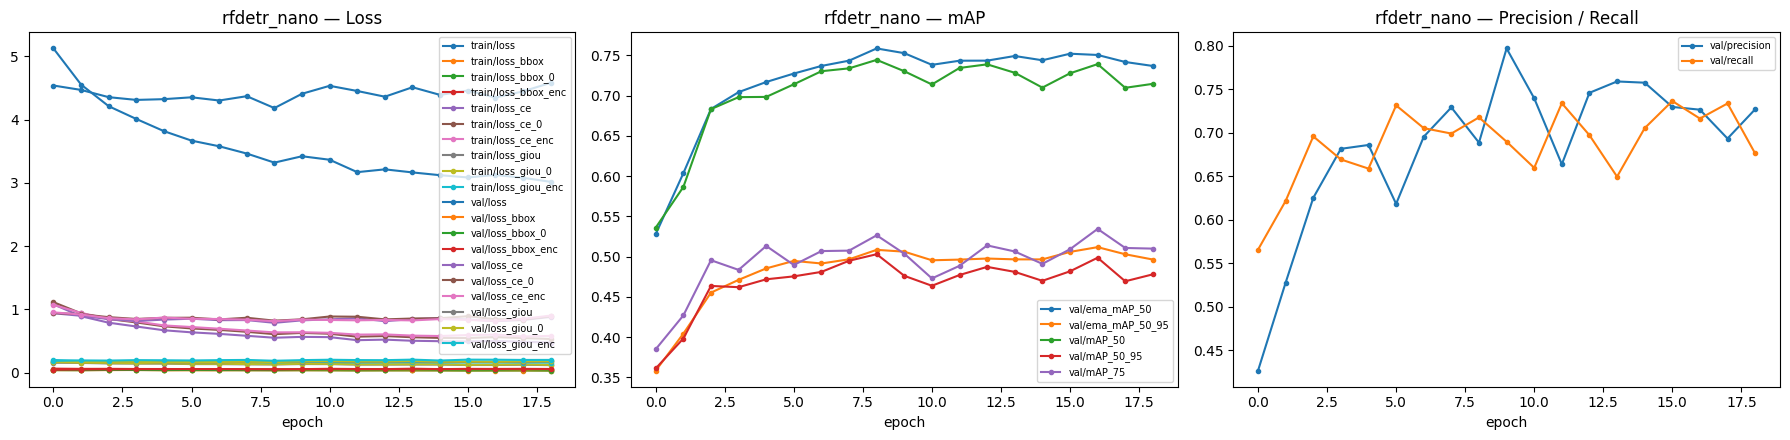

In [10]:
# ==================== TRAINING CURVES ====================

def load_epoch_history_from_csv(metrics_csv_path):
    """Recover per-epoch metrics from Lightning's always-on CSVLogger output.
    Lightning logs one row per step, leaving most columns NaN except whichever
    metric was just logged, so groupby + last-non-null collapses each epoch's
    scattered rows back into one row per epoch."""
    metrics_csv_path = pathlib.Path(metrics_csv_path)
    if not metrics_csv_path.exists():
        raise FileNotFoundError(
            f"{metrics_csv_path} not found — training may not have completed, "
            "or output_dir was cleared. Re-run the training cell first."
        )
    df = pd.read_csv(metrics_csv_path)
    df.columns = [c.strip() for c in df.columns]
    per_epoch = (
        df.groupby("epoch")
        .agg(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan)
        .reset_index()
        .sort_values("epoch")
        .reset_index(drop=True)
    )
    return per_epoch

history_df = load_epoch_history_from_csv(OUTPUT_DIR / "metrics.csv")
print(f"Recovered {len(history_df)} epochs from metrics.csv")
print("columns logged per epoch:", list(history_df.columns))
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

def _plot_matching(ax, df, keyword, title):
    cols = [c for c in df.columns if keyword in c.lower() and df[c].notna().any()]
    for c in cols:
        ax.plot(df["epoch"], df[c], label=c, marker="o", markersize=3)
    ax.set_title(title)
    ax.set_xlabel("epoch")
    if cols:
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no data logged", ha="center", va="center", transform=ax.transAxes)

_plot_matching(axes[0], history_df, "loss", "rfdetr_nano — Loss")
_plot_matching(axes[1], history_df, "map", "rfdetr_nano — mAP")

pr_cols = [c for c in history_df.columns
           if ("precision" in c.lower() or "recall" in c.lower() or c.lower() == "f1")
           and history_df[c].notna().any()]
for c in pr_cols:
    axes[2].plot(history_df["epoch"], history_df[c], label=c, marker="o", markersize=3)
axes[2].set_title("rfdetr_nano — Precision / Recall")
axes[2].set_xlabel("epoch")
if pr_cols:
    axes[2].legend(fontsize=7)
else:
    axes[2].text(0.5, 0.5, "no data logged", ha="center", va="center", transform=axes[2].transAxes)

plt.tight_layout()
plt.show()

---
## 8. Test-Set Evaluation

Run on the held-out **test** split only (never train/val), using the EMA checkpoint — RF-DETR's own
docs note the EMA weights are the ones "commonly used for the final model." `supervision`'s
`MeanAveragePrecision` and `ConfusionMatrix` benchmarking utilities give mAP@50 / mAP@50:95 directly,
and the confusion matrix feeds the same MCC and per-class precision/recall/F1 derivation used for the
three YOLO models in Notebook 2 — same formulas, same test split, so the four-way comparison in
Notebook 4 is apples-to-apples.

In [11]:
# ==================== TEST-SET EVALUATION ====================
best_model = RFDETRNano(pretrain_weights=str(best_ema_pt))

test_dataset = sv.DetectionDataset.from_yolo(
    images_directory_path=str(_test_img_dir),
    annotations_directory_path=str(_test_lbl_dir),
    data_yaml_path=str(DATA_YAML),
)
print(f"test images loaded: {len(test_dataset)}")

def _predict_callback(image):
    return best_model.predict(Image.fromarray(image), threshold=0.5)

map_result = sv.MeanAveragePrecision.benchmark(dataset=test_dataset, callback=_predict_callback)
print(f"mAP50    : {map_result.map50:.4f}")
print(f"mAP50-95 : {map_result.map50_95:.4f}")

confusion_matrix = sv.ConfusionMatrix.benchmark(dataset=test_dataset, callback=_predict_callback)
cm = confusion_matrix.matrix.tolist()   # last row/col = background, same convention as Notebook 2

mcc = compute_mcc_from_confusion_matrix(cm)
per_class = precision_recall_f1_per_class(cm, CLASS_NAMES)

overall_precision = float(np.mean([v["precision"] for v in per_class.values()]))
overall_recall = float(np.mean([v["recall"] for v in per_class.values()]))
overall_f1 = float(np.mean([v["f1"] for v in per_class.values()]))

print(f"\nPrecision (macro): {overall_precision:.4f}")
print(f"Recall    (macro): {overall_recall:.4f}")
print(f"F1        (macro): {overall_f1:.4f}")
print(f"MCC             : {mcc:.4f}")
print(f"\nPer-class breakdown:")
for name, v in per_class.items():
    print(f"  {name:20s} P={v['precision']:.3f}  R={v['recall']:.3f}  F1={v['f1']:.3f}")


[2026-07-11 11:56:16] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-11 11:56:16] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-11 11:56:17] [WARNING] rf-detr - Checkpoint has 7 classes but model is configured for 90. Using checkpoint class count (7). Pass num_classes=7 to suppress this warning.
[2026-07-11 11:56:17] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-07-11 11:56:19] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).


test images loaded: 178
mAP50    : 0.7099
mAP50-95 : 0.5440

Precision (macro): 0.7324
Recall    (macro): 0.6209
F1        (macro): 0.6710
MCC             : 0.4846

Per-class breakdown:
  Artilary             P=0.810  R=0.607  F1=0.694
  Missile              P=0.659  R=0.600  F1=0.628
  Radar                P=0.640  R=0.552  F1=0.593
  M. Rocket Launcher   P=0.742  R=0.639  F1=0.687
  Soldier              P=0.827  R=0.674  F1=0.743
  Tank                 P=0.733  R=0.702  F1=0.717
  Vehicle              P=0.717  R=0.572  F1=0.636


In [12]:
# ==================== INFERENCE SPEED ====================
_test_images_sorted = sorted(_test_img_dir.glob("*"))
speed_info = measure_inference_speed_rfdetr(best_model, _test_images_sorted)
print(f"ms/image : {speed_info['ms_per_image']:.2f}")
print(f"FPS      : {speed_info['fps']:.2f}")

n_params = sum(p.numel() for p in best_model.model.model.parameters()) if hasattr(best_model.model, "model") else None
model_size_mb = best_ema_pt.stat().st_size / (1024 * 1024)
print(f"model size (best_ema.pth): {model_size_mb:.2f} MB")
if n_params:
    print(f"params (M): {n_params / 1e6:.2f}")


ms/image : 32.72
FPS      : 30.56
model size (best_ema.pth): 115.28 MB
params (M): 30.17


---
## 9. Log Results — Same Schema as Notebook 2

In [13]:
results_store["rfdetr_nano"] = {
    "config": {**CONFIG_RFDETR, "model_family": "RF-DETR (transformer/DETR)"},
    "checkpoints": {
        "best_ema_pt": str(best_ema_pt), "best_regular_pt": str(best_regular_pt),
        "best_ema_pt_flat": flat_ema, "best_regular_pt_flat": flat_regular,
    },
    "training_history": history_df.to_dict(orient="list"),
    "final_metrics": {
        "mAP50": float(map_result.map50),
        "mAP50_95": float(map_result.map50_95),
        "precision": overall_precision,
        "recall": overall_recall,
        "f1": overall_f1,
        "mcc": mcc,
        "per_class": per_class,
        "confusion_matrix": {"labels": list(CLASS_NAMES) + ["background"], "matrix": cm},
    },
    "inference": {
        **speed_info,
        "params_millions": (n_params / 1e6) if n_params else None,
        "model_size_mb": model_size_mb,
        "device_used": "GPU 0",
    },
    "training_time_minutes": training_minutes,
}

save_results_store(results_store, RESULTS_JSON)
print(f"Saved to {RESULTS_JSON}")
print("Models logged:", list(results_store.keys()))


Saved to /kaggle/working/model_results.json
Models logged: ['rfdetr_nano']


---
## 10. Summary — Configuration and Final Metrics

In [14]:
summary_rows = []
for model_key, data in results_store.items():
    fm = data["final_metrics"]
    inf = data["inference"]
    summary_rows.append({
        "Model": model_key,
        "Epochs (run)": len(data["training_history"].get("epoch", [])),
        "Batch": data["config"].get("batch_size"),
        "LR": data["config"].get("lr"),
        "mAP50": round(fm["mAP50"], 4),
        "mAP50-95": round(fm["mAP50_95"], 4),
        "Precision": round(fm["precision"], 4),
        "Recall": round(fm["recall"], 4),
        "F1": round(fm["f1"], 4) if fm["f1"] is not None else None,
        "MCC": round(fm["mcc"], 4),
        "FPS": round(inf["fps"], 2),
        "Params (M)": round(inf["params_millions"], 2) if inf.get("params_millions") else None,
        "Size (MB)": round(inf["model_size_mb"], 2),
        "Train time (min)": round(data["training_time_minutes"], 1),
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

print(f"\nAll results and checkpoint paths saved to: {RESULTS_JSON}")
print("This file uses the same schema as Notebook 2's model_results.json — Notebook 4 loads and")
print("merges both files to compare all four models.")


,Model,Epochs (run),Batch,LR,mAP50,mAP50-95,Precision,Recall,F1,MCC,FPS,Params (M),Size (MB),Train time (min)
0,rfdetr_nano,19,4,0.0001,0.7099,0.544,0.7324,0.6209,0.671,0.4846,30.56,30.17,115.28,109.4



All results and checkpoint paths saved to: /kaggle/working/model_results.json
This file uses the same schema as Notebook 2's model_results.json — Notebook 4 loads and
merges both files to compare all four models.


---
## 11. Output Verification for Notebook 4

Everything Notebook 4 needs lives under `/kaggle/working`:
- `checkpoints/` — `rfdetr_nano_best_ema.pt` / `rfdetr_nano_best_regular.pt`
- `model_results.json` — metrics, confusion matrix, per-class scores, inference speed, checkpoint paths

In [15]:
print("Checkpoints in", CHECKPOINT_DIR, ":")
for p in sorted(CHECKPOINT_DIR.glob("*.pt")):
    size_mb = p.stat().st_size / (1024 * 1024)
    print(f"  {p.name}  ({size_mb:.1f} MB)")

print(f"\nresults json exists : {RESULTS_JSON.exists()}")
print(f"models logged       : {list(results_store.keys())}")

if "rfdetr_nano" in results_store:
    print("\nrfdetr_nano logged. Ready to publish as a Kaggle Dataset output.")
else:
    print("\nWARNING — rfdetr_nano missing from results_store.")


Checkpoints in /kaggle/working/checkpoints :
  rfdetr_nano_best_ema.pt  (115.3 MB)
  rfdetr_nano_best_regular.pt  (115.3 MB)

results json exists : True
models logged       : ['rfdetr_nano']

rfdetr_nano logged. Ready to publish as a Kaggle Dataset output.
